In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from pprint import pprint
from tabulate import tabulate
from datetime import datetime, timedelta

In [2]:
file_path = 'Unipol_dataset_lab3.csv' 
data = pd.read_csv(file_path)


In [20]:
# Inspecting a single trip (e.g., Vehicle 1, Trip 0)
trip_inspection = data[(data['vehicle_id'] == 1) & (data['trip_id'] == 100)]
print(trip_inspection[['road', 'total_distance', 'start_time', 'stop_time', 'trip_id']])

    road  total_distance          start_time           stop_time  trip_id
158    A           83.43 2023-10-06 19:11:32 2023-10-06 21:41:05      100
159    E           53.09 2023-10-06 19:11:32 2023-10-06 21:41:05      100
160    U            8.06 2023-10-06 19:11:32 2023-10-06 21:41:05      100


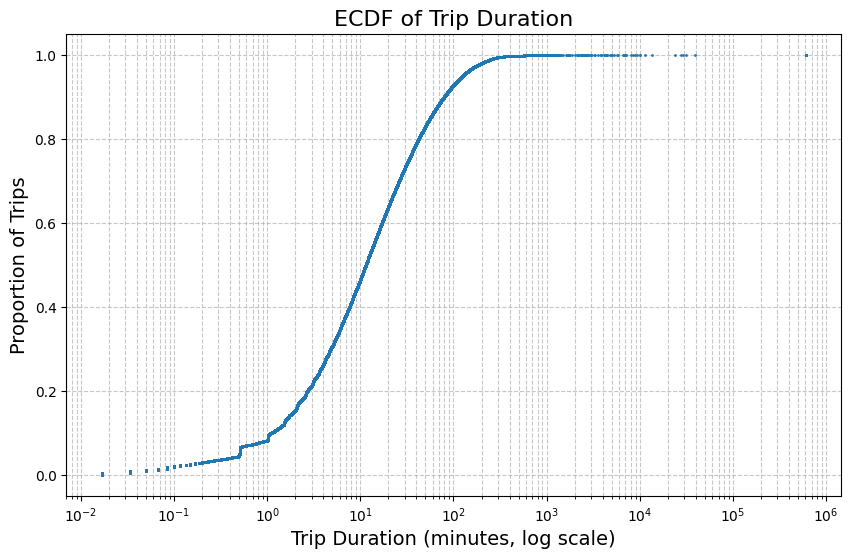

In [3]:

# Check for missing values 
data.dropna(subset=['start_time', 'stop_time'], inplace=True)

data['start_time'] = pd.to_datetime(data['start_time'])
data['stop_time'] = pd.to_datetime(data['stop_time'])


# We only want one record per trip to calculate duration correctly.
unique_trips = data.drop_duplicates(subset=['vehicle_id', 'trip_id']).copy()

# Calculate Duration (in minutes)
unique_trips['trip_duration'] = (unique_trips['stop_time'] - unique_trips['start_time']).dt.total_seconds() / 60

# Filter out zero/negative durations (essential for log scale)
unique_trips = unique_trips[unique_trips['trip_duration'] > 0]

def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

plt.figure(figsize=(10, 6))

x, y = ecdf(unique_trips['trip_duration'])

# Plotting
plt.plot(x, y, marker='.', linestyle='none', markersize=2) 

plt.title('ECDF of Trip Duration', fontsize=16)
plt.xlabel('Trip Duration (minutes, log scale)', fontsize=14)
plt.ylabel('Proportion of Trips', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.7)

# Set Log Scale
plt.xscale('log')

plt.show()

/Users/thatsnegar/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


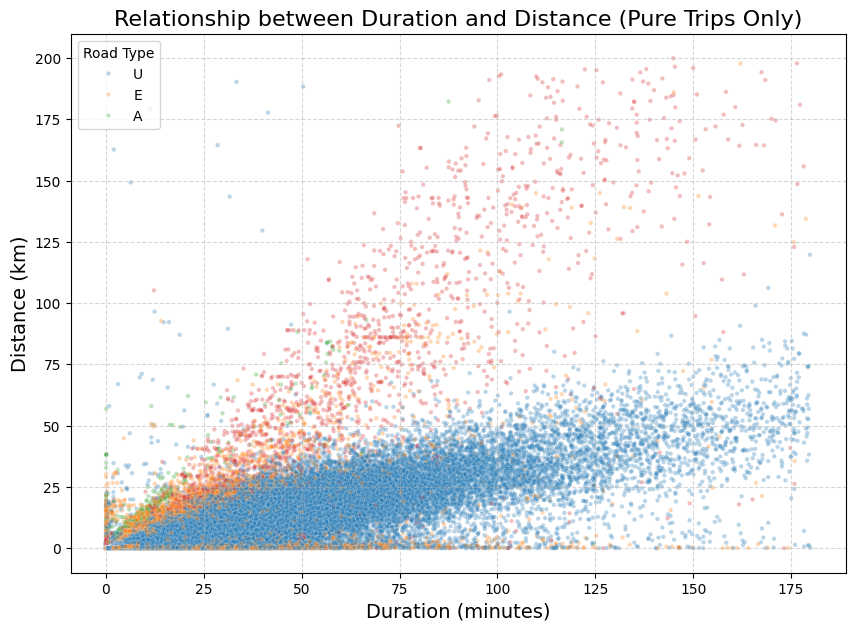

In [6]:
# Convert timestamps
data['start_time'] = pd.to_datetime(data['start_time'])
data['stop_time'] = pd.to_datetime(data['stop_time'])

# Calculate Duration
data['duration_min'] = (data['stop_time'] - data['start_time']).dt.total_seconds() / 60

# Filter for "Pure" Trips (Trips with only 1 road segment)
# We group by Trip ID and keep only groups with exactly 1 row.
# This removes "Mixed" trips (e.g., Urban + Highway) where data is misleading.
trip_counts = data.groupby(['vehicle_id', 'trip_id']).size()
pure_trip_indices = trip_counts[trip_counts == 1].index

# Select these trips from the main dataframe
pure_trips = data.set_index(['vehicle_id', 'trip_id']).loc[pure_trip_indices].reset_index()

# Filter for reasonable limits to make the plot readable (remove extreme outliers)
pure_trips = pure_trips[(pure_trips['total_distance'] < 200) & (pure_trips['duration_min'] < 180)]
pure_trips = pure_trips[pure_trips['total_distance'] > 0] # Remove 0 distance

# Plot Scatter Graph
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pure_trips, 
    x='duration_min', 
    y='total_distance', 
    hue='road', 
    alpha=0.3, 
    s=10       
)

plt.title('Relationship between Duration and Distance (Pure Trips Only)', fontsize=16)
plt.xlabel('Duration (minutes)', fontsize=14)
plt.ylabel('Distance (km)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Road Type')

plt.show()

In [11]:
data['start_time'] = pd.to_datetime(data['start_time'])
data['stop_time'] = pd.to_datetime(data['stop_time'])

data_cleaned_ = data.dropna(subset=['road', 'total_distance', 'start_time', 'stop_time']).copy()


trips_aggregated = data_cleaned_.groupby(['vehicle_id', 'trip_id']).agg({
    'start_time': 'min',         
    'stop_time': 'max',
    'total_distance': 'sum'        
}).reset_index()

# Recalculate duration on the aggregated data
trips_aggregated['trip_duration'] = (trips_aggregated['stop_time'] - trips_aggregated['start_time']).dt.total_seconds() / 60



# Define filtering criteria
min_distance = 0.1
max_distance = 1500
min_duration = 0.5
max_duration = 2500
min_speed = 1
max_speed = 200

# Filter dataset
filtered_trips = trips_aggregated[
    (trips_aggregated['total_distance'] > min_distance) &
    (trips_aggregated['total_distance'] <= max_distance) &
    (trips_aggregated['trip_duration'] > min_duration) &
    (trips_aggregated['trip_duration'] <= max_duration)
].copy()

# Calculate average speed (km/h) using TOTAL distance and TOTAL time
filtered_trips['average_speed'] = (
    filtered_trips['total_distance'] / (filtered_trips['trip_duration'] / 60)
)

# Filter based on speed
filtered_trips = filtered_trips[
    (filtered_trips['average_speed'] >= min_speed) &
    (filtered_trips['average_speed'] <= max_speed)
]

# Count valid trips
valid_trip_count = len(filtered_trips)

print("Filtering Criteria:")
print(f"1. Total distance > {min_distance} km and <= {max_distance} km")
print(f"2. Trip duration > {min_duration} minutes and <= {max_duration} minutes")
print(f"3. Average speed between {min_speed} km/h and {max_speed} km/h")
print(f"Number of valid trips: {valid_trip_count}")

Filtering Criteria:
1. Total distance > 0.1 km and <= 1500 km
2. Trip duration > 0.5 minutes and <= 2500 minutes
3. Average speed between 1 km/h and 200 km/h
Number of valid trips: 765888


**1.**  Analysing behaviours of vehicles. For each vehicle, aggregate the data on daily basis, compute following values:
- number of trips
- total distance
- utilization percetage

In [24]:
filtered_trips.head()

,vehicle_id,trip_id,start_time,stop_time,total_distance,trip_duration,average_speed
0,1,0,2023-09-29 13:55:35,2023-09-29 14:11:42,15.78,16.116667,58.746639
2,1,2,2023-09-29 15:12:03,2023-09-29 15:26:55,4.60,14.866667,18.565022
3,1,3,2023-09-29 15:37:38,2023-09-29 15:57:26,4.25,19.800000,12.878788
6,1,6,2023-09-30 05:05:39,2023-09-30 05:28:37,1.21,22.966667,3.161103
8,1,8,2023-09-30 06:07:07,2023-09-30 06:33:53,5.08,26.766667,11.387298


In [19]:
df = filtered_trips.copy() 

# Extract Date and Day Type
df['date'] = df['start_time'].dt.date
df['day_type'] = df['start_time'].dt.weekday.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Aggregate by Vehicle and Date 
daily_aggregation = df.groupby(['vehicle_id', 'date', 'day_type']).agg(
    num_trips=('trip_id', 'count'),            # Simply count the trips
    total_distance=('total_distance', 'sum'),  # Sum of distances
    total_duration_min=('trip_duration', 'sum') # Sum of durations
).reset_index()

# Calculate Utilization Percentage
# (Total Minutes Driven / Minutes in a Day) * 100
# daily_aggregation['daily_utilization'] = (daily_aggregation['total_duration_min'] / 1440)   
daily_aggregation['daily_utilization'] = daily_aggregation.groupby(['vehicle_id', 'date'])['total_duration_min'].transform('sum') / (24 * 60)  # 24 hours


# Check the results
print(daily_aggregation.head())
print(f"Max Utilization: {daily_aggregation['daily_utilization'].max():.2f}")

   vehicle_id        date day_type  num_trips  total_distance  \
0           1  2023-09-29  Weekday          3          24.630   
1           1  2023-09-30  Weekend          6          11.180   
2           1  2023-10-01  Weekend          1         361.539   
3           1  2023-10-02  Weekday          7         725.195   
4           1  2023-10-03  Weekday          8         519.620   

   total_duration_min  daily_utilization  
0           50.783333           0.035266  
1           69.066667           0.047963  
2          268.983333           0.186794  
3          562.733333           0.390787  
4          478.316667           0.332164  
Max Utilization: 1.79


In [28]:
import pandas as pd

# 1. Load and Preprocess
# We assume 'filtered_trips' contains the valid segments from your previous steps
# If starting from scratch, we ensure 'date' is created:
filtered_trips = pd.read_csv('Unipol_dataset_lab3.csv') # Or use your existing filtered_trips
filtered_trips['start_time'] = pd.to_datetime(filtered_trips['start_time'])

# --- THIS LINE FIXES YOUR ERROR ---
filtered_trips['date'] = filtered_trips['start_time'].dt.date 
# ----------------------------------

# 2. RUN THE COMPARISON

# Method A: Correct (Group by Date ONLY)
# Counts unique trip_ids per day. Even if a trip has 3 segments, it counts as 1.
daily_correct = filtered_trips.groupby(['vehicle_id', 'date']).agg(
    true_trip_count=('trip_id', 'nunique')
).reset_index()

# Method B: Inflated (Group by Road, Then Sum)
# Counts unique trip_ids per road bucket, then adds them up.
road_grouped = filtered_trips.groupby(['vehicle_id', 'date', 'road']).agg(
    road_segment_count=('trip_id', 'nunique')
).reset_index()

daily_inflated = road_grouped.groupby(['vehicle_id', 'date']).agg(
    inflated_trip_count=('road_segment_count', 'sum')
).reset_index()

# 3. Merge and Find Errors
comparison = pd.merge(daily_correct, daily_inflated, on=['vehicle_id', 'date'])
comparison['error_diff'] = comparison['inflated_trip_count'] - comparison['true_trip_count']

# Show the worst offenders
discrepancies = comparison[comparison['error_diff'] > 0].sort_values('error_diff', ascending=False)

print(f"Total Vehicle-Days Analyzed: {len(comparison)}")
print(f"Days with Double-Counting Errors: {len(discrepancies)}")
print("\n--- Top 5 Examples of the Error ---")
print(discrepancies.head(5))

# Example Breakdown for the top result
if not discrepancies.empty:
    top_row = discrepancies.iloc[0]
    vid, date = top_row['vehicle_id'], top_row['date']
    print(f"\nExample: Vehicle {vid} on {date}")
    print(f" - True Trips: {top_row['true_trip_count']}")
    print(f" - Inflated Count: {top_row['inflated_trip_count']} (Error: +{top_row['error_diff']})")

Total Vehicle-Days Analyzed: 56646
Days with Double-Counting Errors: 52503

--- Top 5 Examples of the Error ---
       vehicle_id        date  true_trip_count  inflated_trip_count  \
56325         994  2023-11-16               62                  115   
56287         994  2023-10-09               57                  110   
56284         994  2023-10-06               62                  114   
17449         307  2023-10-02               57                  107   
56289         994  2023-10-11               54                  104   

       error_diff  
56325          53  
56287          53  
56284          52  
17449          50  
56289          50  

Example: Vehicle 994 on 2023-11-16
 - True Trips: 62
 - Inflated Count: 115 (Error: +53)


- 1.a 

In [25]:

# Create 'date' and 'day_type' columns
df['date'] = df['start_time'].dt.date
df['day_type'] = df['start_time'].dt.weekday.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

#Group by Vehicle and Date ONLY 
daily_stats = df.groupby(['vehicle_id', 'date', 'day_type']).agg(
    daily_distance=('total_distance', 'sum'),
    daily_duration=('trip_duration', 'sum'),
    daily_trips=('trip_id', 'count')
).reset_index()

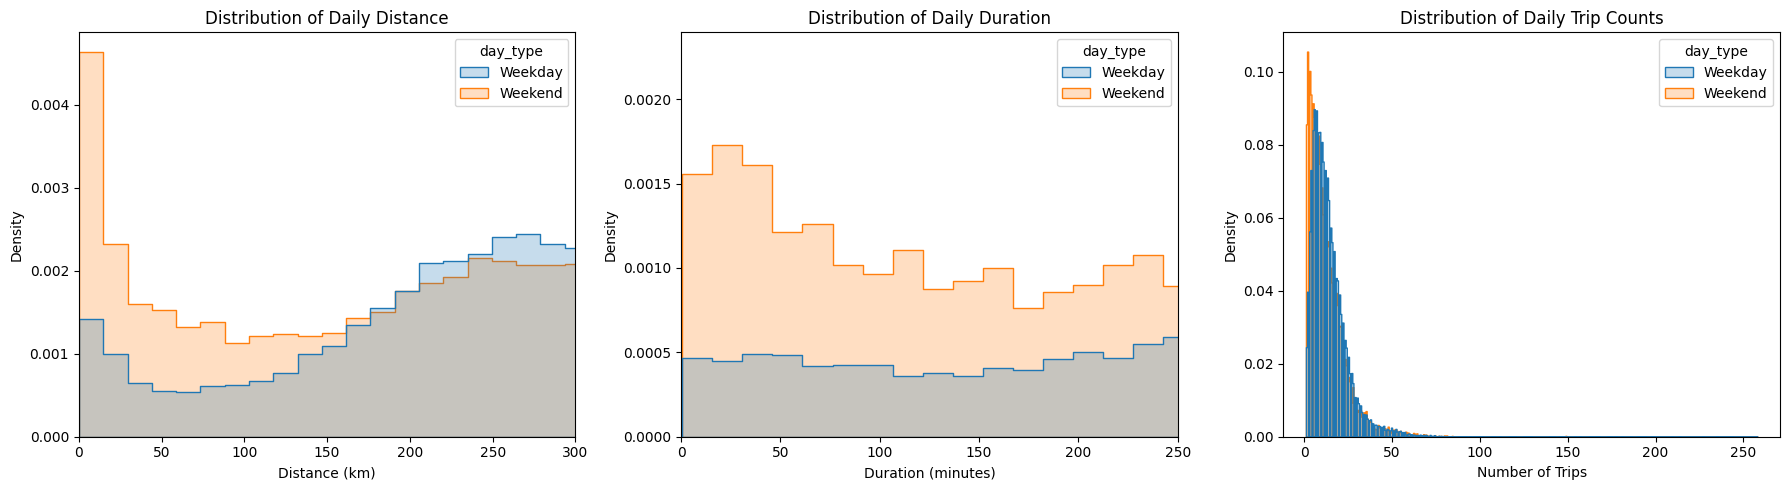

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Daily Distance
sns.histplot(data=daily_stats, x='daily_distance', hue='day_type', 
             element='step', stat='density', common_norm=False, ax=axes[0])
axes[0].set_title('Distribution of Daily Distance')
axes[0].set_xlabel('Distance (km)')
axes[0].set_xlim(0, 300) 

# Plot B: Daily Duration
sns.histplot(data=daily_stats, x='daily_duration', hue='day_type', 
             element='step', stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Distribution of Daily Duration')
axes[1].set_xlabel('Duration (minutes)')
axes[1].set_xlim(0, 250)

# Plot C: Number of Trips
sns.histplot(data=daily_stats, x='daily_trips', hue='day_type', 
             element='step', stat='density', common_norm=False, ax=axes[2])
axes[2].set_title('Distribution of Daily Trip Counts')
axes[2].set_xlabel('Number of Trips')

plt.tight_layout()
plt.show()

In [27]:
print("\n--- Statistics: Weekday vs Weekend ---")
summary_stats = daily_stats.groupby('day_type')[['daily_distance', 'daily_duration', 'daily_trips']].describe(percentiles=[0.5])
print(summary_stats.T)


# Calculate Standard Deviation of daily distance for each vehicle
vehicle_consistency = daily_stats.groupby('vehicle_id')['daily_distance'].std()

print("\n--- Top 5 Most Consistent Vehicles (Lowest Std Dev) ---")
print(vehicle_consistency.sort_values().head(5))

print("\n--- Top 5 Least Consistent Vehicles (Highest Std Dev) ---")
print(vehicle_consistency.sort_values(ascending=False).head(5))


--- Statistics: Weekday vs Weekend ---
day_type                   Weekday       Weekend
daily_distance count  41565.000000  13810.000000
               mean     398.028504    304.930555
               std      253.371526    225.804191
               min        0.110000      0.102000
               50%      339.790000    282.295000
               max     2113.040000   2046.935000
daily_duration count  41565.000000  13810.000000
               mean     531.246032    436.812172
               std      223.729155    267.925252
               min        0.533333      1.266667
               50%      541.316667    443.658333
               max     2574.600000   2509.266667
daily_trips    count  41565.000000  13810.000000
               mean      14.280284     12.478494
               std       11.690690     12.347094
               min        1.000000      1.000000
               50%       12.000000      9.000000
               max      258.000000    237.000000

--- Top 5 Most Consistent Ve

4. conduct the simulation of all the vehicles, with different parameters(types of EV and charging power) and analyse the result 

In [32]:
# prepare data

df = pd.read_csv('Unipol_dataset_lab3.csv')

# Convert timestamps
df['start_time'] = pd.to_datetime(df['start_time'])
df['stop_time'] = pd.to_datetime(df['stop_time'])

# Sort chronologically 
ordered_trips = df.sort_values(by=['vehicle_id', 'start_time']).copy()


print(f"Data Loaded: {len(ordered_trips)} rows ready for simulation.")

Data Loaded: 1415305 rows ready for simulation.


In [37]:
ordered_trips.head()

,Unnamed: 0,vehicle_id,trip_id,start_time,stop_time,road,total_distance
0,0,1,0,2023-09-29 13:55:35,2023-09-29 14:11:42,E,14.31
1,1,1,0,2023-09-29 13:55:35,2023-09-29 14:11:42,U,1.47
2,2,1,1,2023-09-29 14:32:24,2023-09-29 14:34:31,U,0.03
3,3,1,2,2023-09-29 15:12:03,2023-09-29 15:26:55,E,2.60
4,4,1,2,2023-09-29 15:12:03,2023-09-29 15:26:55,U,2.00


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi


# Global Thresholds
FAST_CHARGING_SOC_THRESHOLD = 0.20  # < 20% SoC
FAST_CHARGING_TIME_THRESHOLD = 2.0  # < 2 Hours

cars_config = {
    "Renault Twingo (27kWh)": {
        "capacity": 27.5, "ac_power": 6.6, "dc_power": 50.0,
        "consumption": {"U": 0.096, "A": 0.162, "E": 0.128, "_": 0.128}
    },
    "Fiat 500e (37kWh)": {
        "capacity": 37.3, "ac_power": 11.0, "dc_power": 85.0,
        "consumption": {"U": 0.105, "A": 0.173, "E": 0.138, "_": 0.138}
    },
    "CUPRA Born (77kWh)": {
        "capacity": 77.0, "ac_power": 11.0, "dc_power": 175.0,
        "consumption": {"U": 0.118, "A": 0.186, "E": 0.150, "_": 0.150}
    },
    "BYD SEAL (82.5kWh)": {
        "capacity": 82.5, "ac_power": 11.0, "dc_power": 150.0,
        "consumption": {"U": 0.121, "A": 0.181, "E": 0.149, "_": 0.149}
    },
    "BMW iX (71kWh)": {
        "capacity": 71.0, "ac_power": 11.0, "dc_power": 148.0,
        "consumption": {"U": 0.138, "A": 0.215, "E": 0.175, "_": 0.175}
    },
    "Lotus Eletre (109kWh)": {
        "capacity": 109.0, "ac_power": 22.0, "dc_power": 367.0,
        "consumption": {"U": 0.156, "A": 0.242, "E": 0.196, "_": 0.196}
    },
    "VW ID.Buzz (77kWh)": {
        "capacity": 77.0, "ac_power": 11.0, "dc_power": 175.0,
        "consumption": {"U": 0.154, "A": 0.252, "E": 0.200, "_": 0.200}
    },
    "Audi e-tron GT (85kWh)": {
        "capacity": 85.0, "ac_power": 11.0, "dc_power": 268.0,
        "consumption": {"U": 0.150, "A": 0.227, "E": 0.185, "_": 0.185}
    }
}

def init_metrics_structure():
    """Initializes the exact metrics dictionary from Pseudocode"""
    return {
        "feasibility": {
            "total_trips": 0, "feasible_trips": 0, "unfeasible_trips": 0
        },
        "battery_perf": {
            "soc_values": [], "soc_below_20_count": 0
        },
        "charging": {
            "total_events": 0, "total_time_hours": 0.0,
            "slow_events": 0, "fast_events": 0,
            "durations": []
        },
        "energy": {
            "total_consumed_kwh": 0.0, "total_distance_km": 0.0
        }
    }

# ==============================================================================
# SIMULATION LOOP
# ==============================================================================
def run_simulation(trips_df, car_name, car_params):
    print(f"Simulating: {car_name}...")
    
    # Initialize Data
    trips = trips_df.sort_values(by=['vehicle_id', 'start_time']).copy()
    trip_log = [] # To store detailed trip results
    
    # Global metrics for this car model
    model_metrics = init_metrics_structure()

    # Vehicle Loop
    for vid, vehicle_trips in trips.groupby('vehicle_id'):
        
        # Initialize SoC
        battery_cap = car_params['capacity']
        current_soc = battery_cap
        
        trip_list = vehicle_trips.to_dict('records')
        
        # Trip Loop
        for i, trip in enumerate(trip_list):
            
            # --- Calculate Energy Required ---
            dist = trip['total_distance']
            road = trip['road'] if trip['road'] in ['U', 'A', 'E'] else '_'
            consumption_rate = car_params['consumption'][road]
            energy_needed = dist * consumption_rate
            
            # Tracking "SoC Before" for logging
            soc_before = current_soc
            status = "Feasible"

            # --- Check Feasibility ---
            model_metrics['feasibility']['total_trips'] += 1
            
            if current_soc >= energy_needed:
                # Feasible
                current_soc -= energy_needed
                
                # Update Metrics
                model_metrics['feasibility']['feasible_trips'] += 1
                model_metrics['energy']['total_consumed_kwh'] += energy_needed
                model_metrics['energy']['total_distance_km'] += dist
                model_metrics['battery_perf']['soc_values'].append(current_soc / battery_cap * 100)
                
                if (current_soc / battery_cap) < 0.20:
                    model_metrics['battery_perf']['soc_below_20_count'] += 1
            else:
                # Unfeasible
                status = "Unfeasible"
                model_metrics['feasibility']['unfeasible_trips'] += 1
                
                # Rescue Logic (Implicit assumption to continue simulation)
                current_soc = battery_cap * 0.20 
            
            soc_after = current_soc

            # --- Calculate Parking Duration ---
            parking_time = 0
            charge_type = "None"
            energy_recharged = 0
            
            if i < len(trip_list) - 1:
                next_start = trip_list[i+1]['start_time']
                current_end = trip['stop_time']
                parking_time = max(0, (next_start - current_end).total_seconds() / 3600)
                
                # --- Charging Logic ---
                if parking_time > 0:
                    power = 0
                    
                    # Determine Charging Type
                    is_low_soc = current_soc < (FAST_CHARGING_SOC_THRESHOLD * battery_cap)
                    is_short_stop = (parking_time < FAST_CHARGING_TIME_THRESHOLD) and (current_soc < (battery_cap * 0.8))
                    
                    if is_low_soc or is_short_stop:
                        # Fast Charging
                        power = car_params['dc_power']
                        charge_type = "Fast (DC)"
                        model_metrics['charging']['fast_events'] += 1
                    else:
                        # Slow Charging
                        power = car_params['ac_power']
                        charge_type = "Slow (AC)"
                        model_metrics['charging']['slow_events'] += 1
                    
                    # Calculate Energy Recharged
                    energy_needed_to_full = battery_cap - current_soc
                    time_to_full = energy_needed_to_full / power if power > 0 else 0
                    actual_charging_time = min(parking_time, time_to_full)
                    
                    # Update Battery
                    energy_recharged = power * actual_charging_time
                    current_soc = min(current_soc + energy_recharged, battery_cap)
                    
                    # Update Charging Metrics
                    model_metrics['charging']['total_events'] += 1
                    model_metrics['charging']['total_time_hours'] += actual_charging_time
                    model_metrics['charging']['durations'].append(actual_charging_time)

            # --- Store Trip Results ---
            trip_log.append({
                'car_model': car_name,
                'vehicle_id': vid,
                'trip_id': trip.get('trip_id', i), # Safety get
                'soc_before': (soc_before / battery_cap) * 100,
                'soc_after': (soc_after / battery_cap) * 100,
                'status': status,
                'energy_consumed': energy_needed,
                'parking_time': parking_time,
                'charge_type': charge_type,
                'energy_recharged': energy_recharged
            })

    return pd.DataFrame(trip_log), model_metrics

# ==============================================================================
# EXECUTION & METRICS AGGREGATION
# ==============================================================================
all_trip_logs = []
model_summaries = []

for model_name, params in cars_config.items():
    
    # Run Simulation
    df_log, raw_metrics = run_simulation(ordered_trips, model_name, params)
    all_trip_logs.append(df_log)
    
    # Metrics Calculation (Aggregating the accumulated counts)
    f_metrics = raw_metrics['feasibility']
    b_metrics = raw_metrics['battery_perf']
    c_metrics = raw_metrics['charging']
    e_metrics = raw_metrics['energy']
    
    # Calculations
    total_trips = f_metrics['total_trips']
    feasible_pct = (f_metrics['feasible_trips'] / total_trips * 100) if total_trips > 0 else 0
    
    avg_soc = np.mean(b_metrics['soc_values']) if b_metrics['soc_values'] else 0
    min_soc = np.min(b_metrics['soc_values']) if b_metrics['soc_values'] else 0
    
    avg_charge_duration = (c_metrics['total_time_hours'] / c_metrics['total_events']) if c_metrics['total_events'] > 0 else 0
    fast_ratio = (c_metrics['fast_events'] / c_metrics['total_events'] * 100) if c_metrics['total_events'] > 0 else 0
    
    avg_energy_km = (e_metrics['total_consumed_kwh'] * 1000) / e_metrics['total_distance_km'] if e_metrics['total_distance_km'] > 0 else 0
    
    # Store Summary
    model_summaries.append({
        'Car Model': model_name,
        'Feasibility %': feasible_pct,
        'Unfeasible Trips': f_metrics['unfeasible_trips'],
        'Avg SoC (%)': avg_soc,
        'Min SoC (%)': min_soc,
        'SoC < 20% Count': b_metrics['soc_below_20_count'],
        'Total Charging Events': c_metrics['total_events'],
        'Avg Charge Duration (h)': avg_charge_duration,
        'Fast Charge Ratio (%)': fast_ratio,
        'Efficiency (Wh/km)': avg_energy_km,
        'Total Energy (kWh)': e_metrics['total_consumed_kwh']
    })

# Create Final DataFrames
final_trip_data = pd.concat(all_trip_logs)
comparison_df = pd.DataFrame(model_summaries)

print("\n--- Simulation Complete. Comparison Table Created. ---")
print(comparison_df[['Car Model', 'Feasibility %', 'Efficiency (Wh/km)', 'Fast Charge Ratio (%)']])



Simulating: Renault Twingo (27kWh)...
Simulating: Fiat 500e (37kWh)...
Simulating: CUPRA Born (77kWh)...
Simulating: BYD SEAL (82.5kWh)...
Simulating: BMW iX (71kWh)...
Simulating: Lotus Eletre (109kWh)...
Simulating: VW ID.Buzz (77kWh)...
Simulating: Audi e-tron GT (85kWh)...

--- Simulation Complete. Comparison Table Created. ---
                Car Model  Feasibility %  Efficiency (Wh/km)  \
0  Renault Twingo (27kWh)      97.407131          125.814716   
1       Fiat 500e (37kWh)      98.484638          137.898243   
2      CUPRA Born (77kWh)      99.780471          154.860158   
3      BYD SEAL (82.5kWh)      99.819120          153.588746   
4          BMW iX (71kWh)      99.460116          178.622163   
5   Lotus Eletre (109kWh)      99.857840          202.848339   
6      VW ID.Buzz (77kWh)      99.347985          204.509170   
7  Audi e-tron GT (85kWh)      99.721403          191.117020   

   Fast Charge Ratio (%)  
0              28.006070  
1              20.596793  
2       

### Metric calcultion :
1. **Feasibility:**
2. **Battery Performance:**
3. **Charging:**
4. **Energy Efficiency:**

In [59]:
final_report = comparison_df[[
    'Car Model', 
    'Feasibility %',           # 1. Feasibility
    'Avg SoC (%)',             # 2. Battery Performance (Mean)
    'Min SoC (%)',             # 2. Battery Performance (Min)
    'Avg Charge Duration (h)', # 3. Charging (Duration)
    'Fast Charge Ratio (%)',   # 3. Charging (Ratio)
    'Efficiency (Wh/km)'       # 4. Energy Efficiency
]].copy()

final_report['Feasibility %'] = final_report['Feasibility %'].map('{:.2f}%'.format)
final_report['Avg SoC (%)'] = final_report['Avg SoC (%)'].map('{:.1f}%'.format)
final_report['Min SoC (%)'] = final_report['Min SoC (%)'].map('{:.1f}%'.format)
final_report['Avg Charge Duration (h)'] = final_report['Avg Charge Duration (h)'].map('{:.2f} h'.format)
final_report['Fast Charge Ratio (%)'] = final_report['Fast Charge Ratio (%)'].map('{:.1f}%'.format)
final_report['Efficiency (Wh/km)'] = final_report['Efficiency (Wh/km)'].map('{:.1f} Wh/km'.format)

print("--- Final Performance Report per EV Model ---")
print(final_report.to_string(index=False))

--- Final Performance Report per EV Model ---
             Car Model Feasibility % Avg SoC (%) Min SoC (%) Avg Charge Duration (h) Fast Charge Ratio (%) Efficiency (Wh/km)
Renault Twingo (27kWh)        97.41%       78.0%        0.0%                  0.13 h                 28.0%        125.8 Wh/km
     Fiat 500e (37kWh)        98.48%       82.4%        0.0%                  0.10 h                 20.6%        137.9 Wh/km
    CUPRA Born (77kWh)        99.78%       88.1%        0.0%                  0.14 h                 11.2%        154.9 Wh/km
    BYD SEAL (82.5kWh)        99.82%       88.3%        0.0%                  0.15 h                 11.1%        153.6 Wh/km
        BMW iX (71kWh)        99.46%       85.7%        0.0%                  0.14 h                 15.2%        178.6 Wh/km
 Lotus Eletre (109kWh)        99.86%       90.1%        0.0%                  0.10 h                  8.4%        202.8 Wh/km
    VW ID.Buzz (77kWh)        99.35%       85.1%        0.0%            

1. **Feasibility:**

- Feasibility => Lotus Eletre (99.86%) and BYD SEAL (99.82%) are nearly perfect, their large batteries allow them to handle almost any trip in the simulation 

- Renault Twingo (97.41%) and Fiat 500e (98.48%) => lower performance but still high 

###### ------------------------------------------------------------------------------------------------------------------------------------------------------
######
2. **Battery Performance:**
- Avg SOC : avg battery level maintained during operation 
- Larger batteries maintain a higher "buffer." The Lotus Eletre sits comfortably at 90.1%, whereas the Twingo drops to 78.0%. This indicates the smaller cars are being pushed closer to their limits more frequently.
- Every single model hit a Minimum SoC of 0.0%.

###### ------------------------------------------------------------------------------------------------------------------------------------------------------
######
3. **Charging:**
- Fast Charge Ratio: The percentage of charging sessions that used high-power (DC) fast chargers rather than slow (AC) chargers.

- Small Batteries = More Stress: The Renault Twingo has the highest ratio at 28.0%. Because its range is short, it frequently needs "emergency" fast top-ups to keep working.

Large Batteries = More Flexibility: The Lotus Eletre has the lowest ratio (8.4%). It can likely complete its daily duties on a single charge and recharge slowly overnight.
###### ------------------------------------------------------------------------------------------------------------------------------------------------------
######
4. **Energy Efficiency:**

- How much energy is used per kilometer (Wh/km). Lower is better.
- Most Efficient: The Renault Twingo (125.8 Wh/km) is the most economical to run per kilometer, followed by the Fiat 500e.
- The VW ID.Buzz (204.5 Wh/km) and Lotus Eletre (202.8 Wh/km) are the heaviest consumers.

In [62]:
df = pd.DataFrame(model_summaries)

sns.set_theme(style="whitegrid")



1. **Feasibility Comparison:**
    - Bar chart: Feasible trips percentage per EV model
    - Bar chart: Unfeasible trips count per EV model

- Result => 

/var/folders/_4/95zfln_91r51q76wysxzqmg00000gn/T/ipykernel_1782/902789227.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y='Car Model', x='Feasibility %', ax=axes[0], palette='viridis')
/var/folders/_4/95zfln_91r51q76wysxzqmg00000gn/T/ipykernel_1782/902789227.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y='Car Model', x='Unfeasible Trips', ax=axes[1], palette='magma')


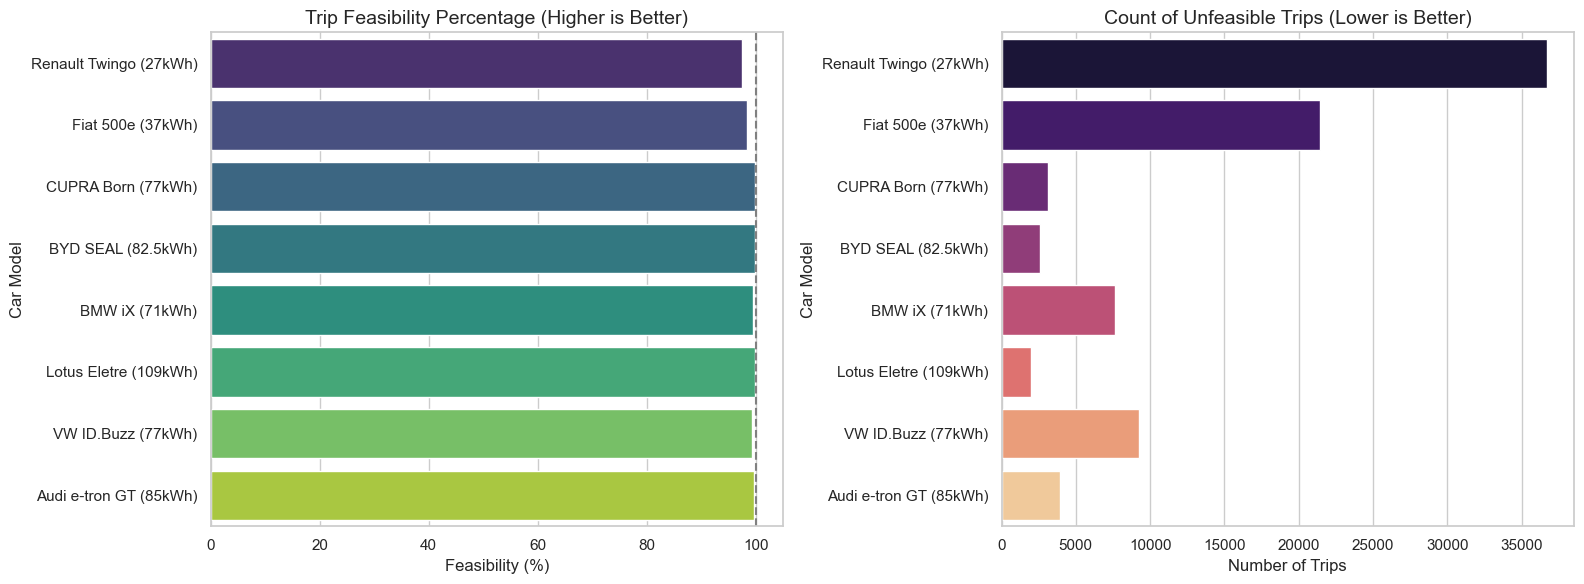

In [63]:
# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Feasibility Percentage
sns.barplot(data=df, y='Car Model', x='Feasibility %', ax=axes[0], palette='viridis')
axes[0].set_title('Trip Feasibility Percentage (Higher is Better)', fontsize=14)
axes[0].set_xlabel('Feasibility (%)')
axes[0].set_xlim(0, 105)  # Percentage scale
axes[0].axvline(100, color='grey', linestyle='--') # 100% marker

# Plot 2: Unfeasible Trips Count
sns.barplot(data=df, y='Car Model', x='Unfeasible Trips', ax=axes[1], palette='magma')
axes[1].set_title('Count of Unfeasible Trips (Lower is Better)', fontsize=14)
axes[1].set_xlabel('Number of Trips')

plt.tight_layout()
plt.show()

2. **Battery SoC Over Time:**
    - Line plot: SoC evolution for sample vehicles from each model
    - Distribution plot: SoC distribution across all trips

/var/folders/_4/95zfln_91r51q76wysxzqmg00000gn/T/ipykernel_1782/1760157935.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y='Car Model', x='Avg SoC (%)', ax=axes[0], palette='Blues')
/var/folders/_4/95zfln_91r51q76wysxzqmg00000gn/T/ipykernel_1782/1760157935.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y='Car Model', x='SoC < 20% Count', ax=axes[1], palette='Reds')


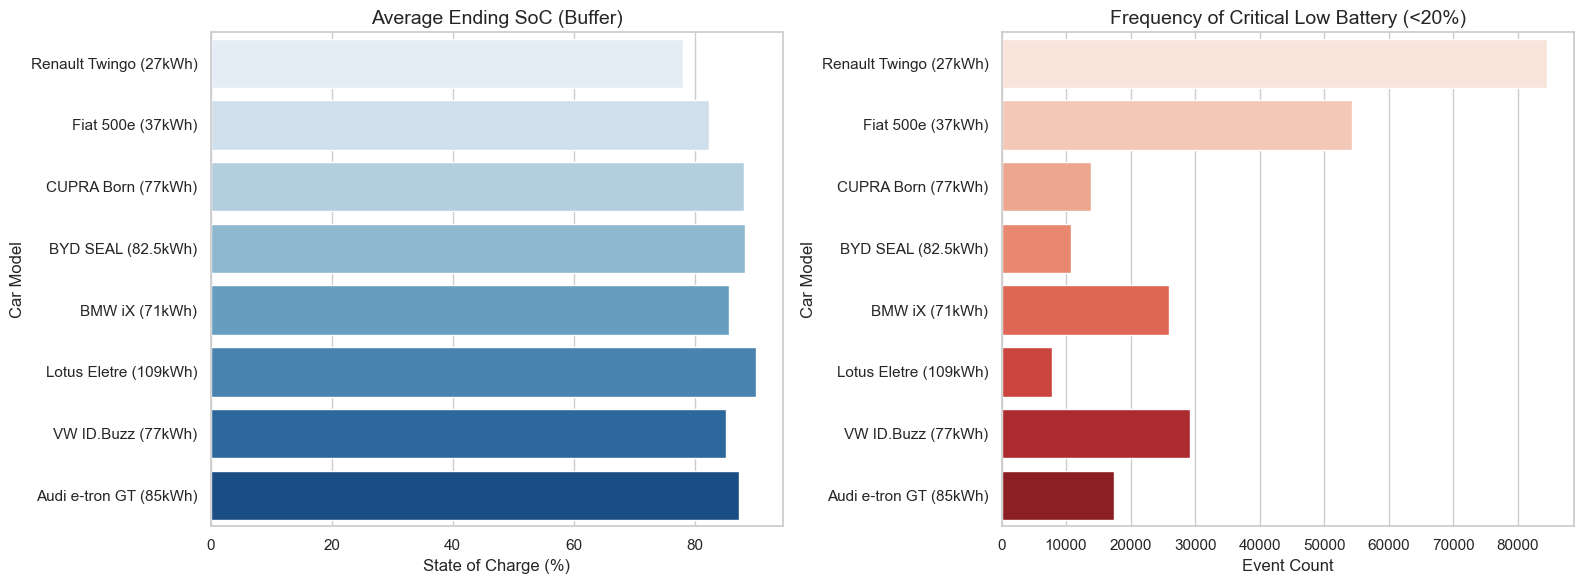

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average Ending SoC
sns.barplot(data=df, y='Car Model', x='Avg SoC (%)', ax=axes[0], palette='Blues')
axes[0].set_title('Average Ending SoC (Buffer)', fontsize=14)
axes[0].set_xlabel('State of Charge (%)')

# Plot 2: Critical Low Battery Events
sns.barplot(data=df, y='Car Model', x='SoC < 20% Count', ax=axes[1], palette='Reds')
axes[1].set_title('Frequency of Critical Low Battery (<20%)', fontsize=14)
axes[1].set_xlabel('Event Count')

plt.tight_layout()
plt.show()

3. **Charging Analysis:**
    - Bar chart: Total charging events per EV model
    - Pie chart: Fast vs Slow charging ratio per model


/var/folders/_4/95zfln_91r51q76wysxzqmg00000gn/T/ipykernel_1782/3844098173.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y='Car Model', x='Total Charging Events', ax=axes[0], palette='Purples')
/var/folders/_4/95zfln_91r51q76wysxzqmg00000gn/T/ipykernel_1782/3844098173.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y='Car Model', x='Fast Charge Ratio (%)', ax=axes[1], palette='Oranges')


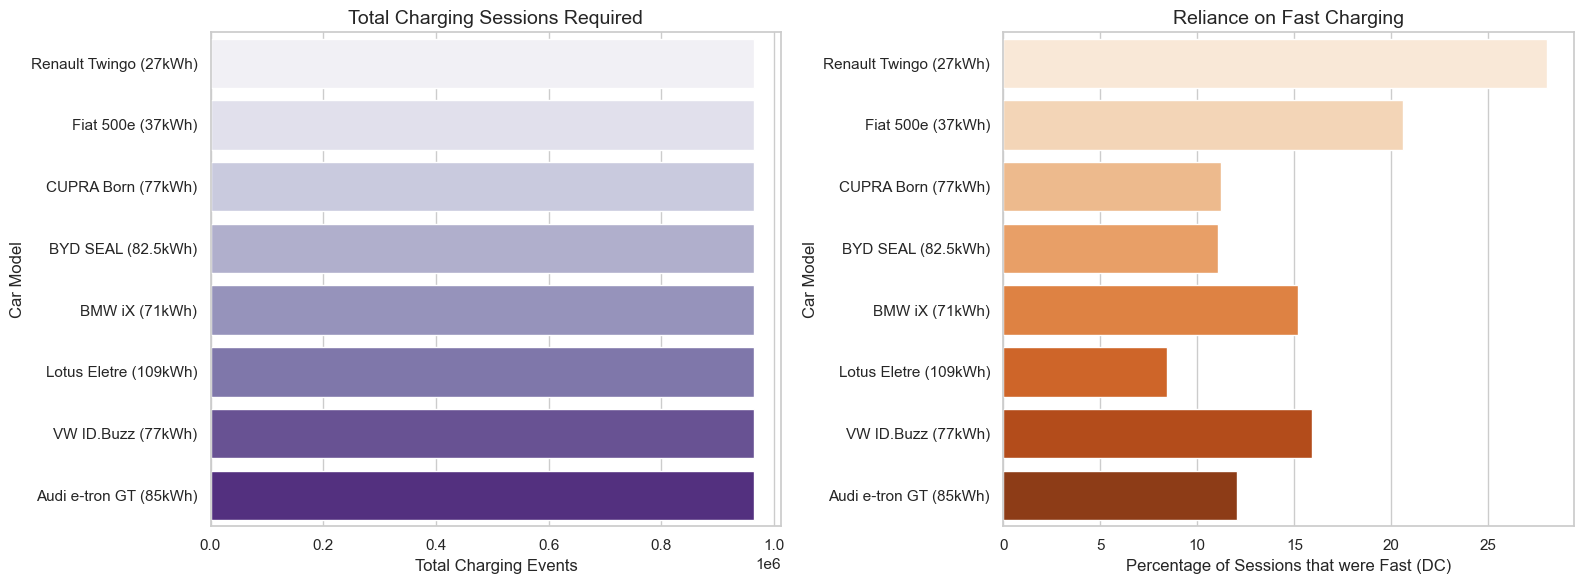

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Total Charging Events
sns.barplot(data=df, y='Car Model', x='Total Charging Events', ax=axes[0], palette='Purples')
axes[0].set_title('Total Charging Sessions Required', fontsize=14)

# Plot 2: Fast Charging Ratio
# (Using hue=None to avoid warnings, mapping values to color)
sns.barplot(data=df, y='Car Model', x='Fast Charge Ratio (%)', ax=axes[1], palette='Oranges')
axes[1].set_title('Reliance on Fast Charging', fontsize=14)
axes[1].set_xlabel('Percentage of Sessions that were Fast (DC)')

plt.tight_layout()
plt.show()

4. **Energy Efficiency:**
    - Bar chart: Average energy consumption (Wh/km) per model
    - Scatter plot: Energy consumption vs distance per trip

/var/folders/_4/95zfln_91r51q76wysxzqmg00000gn/T/ipykernel_1782/1559020118.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted, y='Car Model', x='Efficiency (Wh/km)', palette='GnBu')


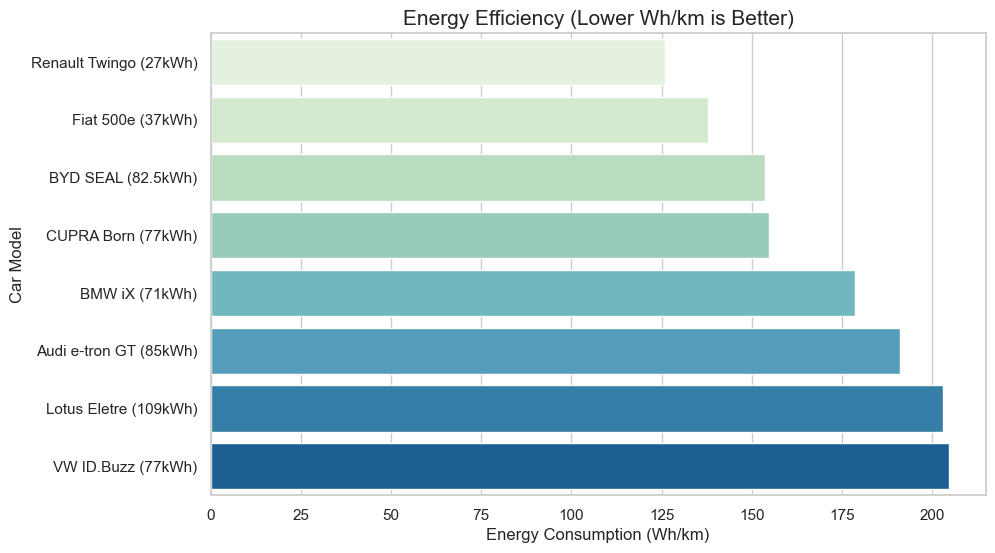

In [66]:
plt.figure(figsize=(10, 6))

# Sort by efficiency for better readability (Most efficient on top)
df_sorted = df.sort_values('Efficiency (Wh/km)')

sns.barplot(data=df_sorted, y='Car Model', x='Efficiency (Wh/km)', palette='GnBu')

plt.title('Energy Efficiency (Lower Wh/km is Better)', fontsize=15)
plt.xlabel('Energy Consumption (Wh/km)')
plt.show()

5. **Comprehensive Dashboard:**

    - Heatmap: All metrics normalized across EV models
    - Radar chart: Multi-metric comparison of EV models

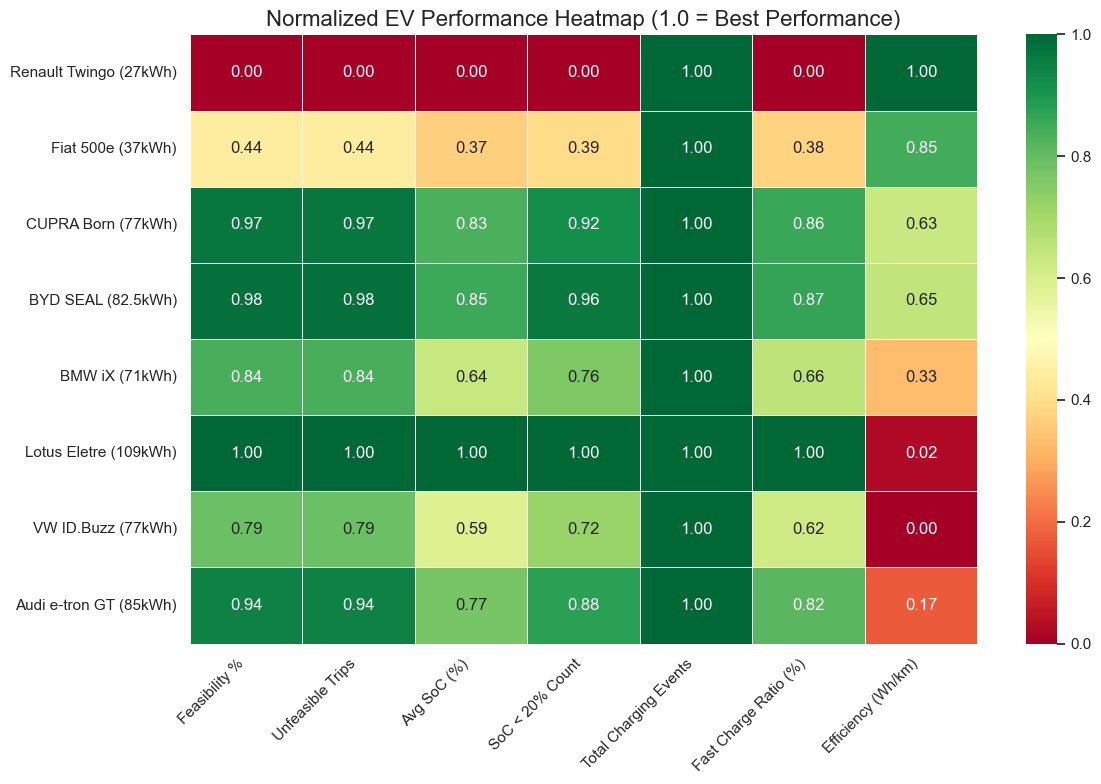

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare Data (Assuming 'model_summaries' list exists from previous step)
# If running standalone, ensure you have the 'df' DataFrame loaded:
# df = pd.DataFrame(model_summaries)

# Select relevant numeric columns for the heatmap
heatmap_cols = [
    'Feasibility %', 
    'Unfeasible Trips', 
    'Avg SoC (%)', 
    'SoC < 20% Count', 
    'Total Charging Events', 
    'Fast Charge Ratio (%)', 
    'Efficiency (Wh/km)'
]

# Create a copy to avoid modifying original data
heatmap_df = df.set_index('Car Model')[heatmap_cols].copy()

# 2. Normalize Data (0 to 1 Scale)
# Logic: We want 1.0 to always mean "Good" and 0.0 to mean "Bad"
for col in heatmap_df.columns:
    
    # Identify "Lower is Better" columns
    if col in ['Unfeasible Trips', 'SoC < 20% Count', 'Total Charging Events', 
               'Fast Charge Ratio (%)', 'Efficiency (Wh/km)']:
        # Invert logic: (Max - Value) / (Max - Min)
        # This way, the Lowest value gets a score of 1.0 (Best)
        min_val = heatmap_df[col].min()
        max_val = heatmap_df[col].max()
        if max_val != min_val:
            heatmap_df[col] = (max_val - heatmap_df[col]) / (max_val - min_val)
        else:
            heatmap_df[col] = 1.0 # If all values are same, give full score
            
    else:
        # Standard logic (Higher is Better): (Value - Min) / (Max - Min)
        min_val = heatmap_df[col].min()
        max_val = heatmap_df[col].max()
        if max_val != min_val:
            heatmap_df[col] = (heatmap_df[col] - min_val) / (max_val - min_val)
        else:
            heatmap_df[col] = 1.0

# 3. Plot Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_df, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=.5)

plt.title('Normalized EV Performance Heatmap (1.0 = Best Performance)', fontsize=16)
plt.ylabel('') # Remove y-label for cleaner look
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- 4.a : report and comment how many trips are unfeasible(the SOC is or arrive at 0)

/var/folders/_4/95zfln_91r51q76wysxzqmg00000gn/T/ipykernel_1782/3610763193.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


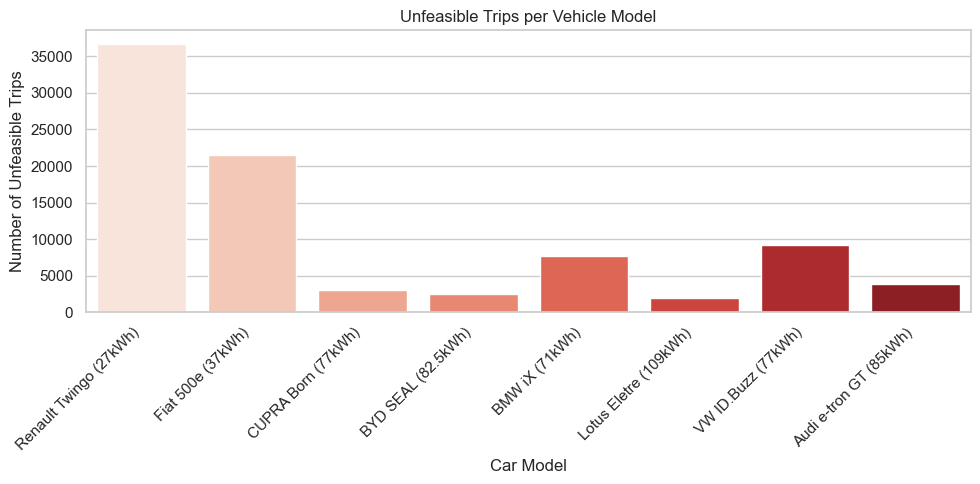

In [71]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=comparison_df,
    x='Car Model',
    y='Unfeasible Trips',
    palette='Reds'
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Unfeasible Trips')
plt.xlabel('Car Model')
plt.title('Unfeasible Trips per Vehicle Model')

plt.tight_layout()
plt.show()


Figure X illustrates the number of unfeasible trips for each vehicle model. Unfeasible trips are defined as trips for which the available battery State of Charge (SoC) at the start of the trip is insufficient to satisfy the required energy demand.

The results show a strong dependency on battery capacity and vehicle efficiency. The Renault Twingo (27 kWh) exhibits by far the highest number of unfeasible trips, followed by the Fiat 500e (37 kWh). This outcome is expected, as vehicles with smaller battery capacities are more likely to experience energy shortages during longer or consecutive trips.

In contrast, vehicles equipped with larger batteries, such as the CUPRA Born (77 kWh), BYD SEAL (82.5 kWh), Lotus Eletre (109 kWh), and Audi e-tron GT (85 kWh), show a substantially lower number of unfeasible trips, indicating a higher robustness in handling the trip demand present in the dataset.

An interesting case is the VW ID.Buzz (77 kWh), which presents a higher number of unfeasible trips compared to other vehicles with similar battery capacity. This behavior can be attributed to its higher energy consumption per kilometer, demonstrating that battery size alone is not sufficient to guarantee trip feasibility, and vehicle efficiency plays a crucial role.

It is important to note that, following an unfeasible trip, the simulation applies a recovery assumption by resetting the battery SoC to 20% to allow subsequent trips to be simulated. Therefore, unfeasible trips represent critical energy shortage events, rather than complete vehicle failure.

- 4.b : Report and comment the distribution of performance metrics over vehicles

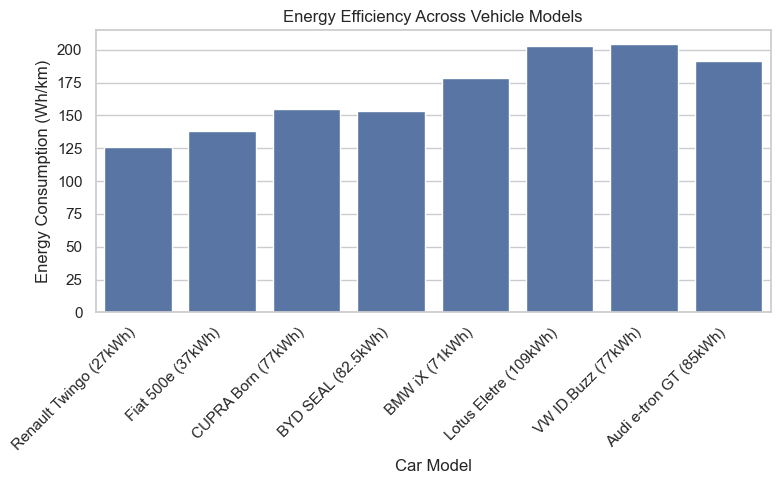

In [72]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=comparison_df,
    x='Car Model',
    y='Efficiency (Wh/km)'
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Energy Consumption (Wh/km)')
plt.title('Energy Efficiency Across Vehicle Models')
plt.tight_layout()
plt.show()


Figure X presents the average energy consumption per kilometer for each vehicle model. A clear increasing trend can be observed from compact vehicles to larger and heavier models. The Renault Twingo and Fiat 500e exhibit the lowest energy consumption, reflecting their smaller size and lower mass. In contrast, larger vehicles such as the Lotus Eletre, VW ID.Buzz, and Audi e-tron GT show significantly higher energy consumption values, exceeding 180 Wh/km.



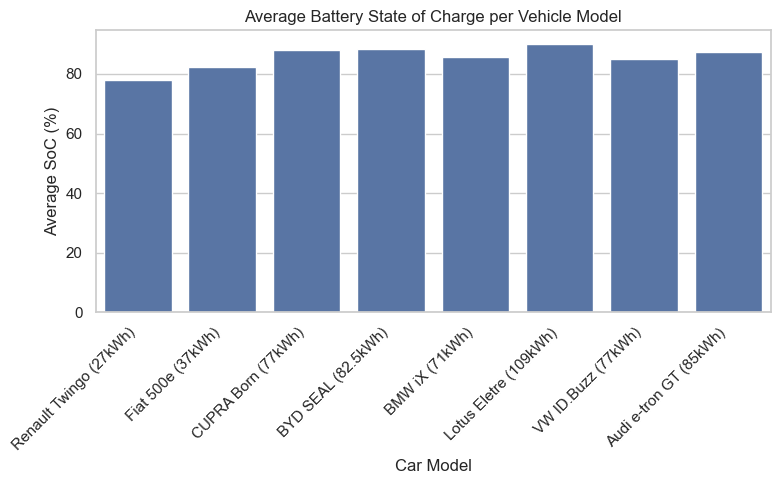

In [73]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=comparison_df,
    x='Car Model',
    y='Avg SoC (%)'
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average SoC (%)')
plt.title('Average Battery State of Charge per Vehicle Model')
plt.tight_layout()
plt.show()


Figure Y shows the average State of Charge maintained by each vehicle throughout the simulation. Vehicles with larger battery capacities generally maintain higher average SoC levels. In particular, the Lotus Eletre and BYD SEAL exhibit the highest average SoC values, indicating a more robust energy buffer during operation.

Conversely, smaller battery vehicles such as the Renault Twingo and Fiat 500e maintain lower average SoC values, suggesting a more constrained operational regime and increased vulnerability to energy shortages during consecutive trips.

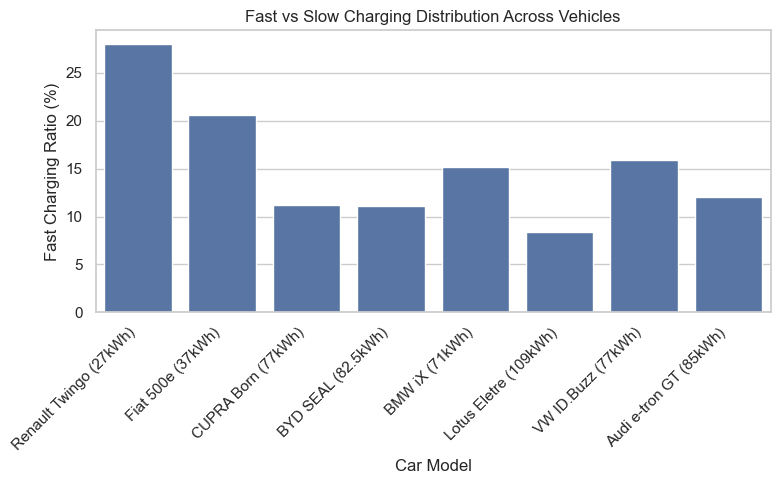

In [74]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=comparison_df,
    x='Car Model',
    y='Fast Charge Ratio (%)'
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Fast Charging Ratio (%)')
plt.title('Fast vs Slow Charging Distribution Across Vehicles')
plt.tight_layout()
plt.show()


Figure Z illustrates the distribution of fast charging events relative to total charging events. Smaller battery vehicles show a higher reliance on fast charging, with the Renault Twingo and Fiat 500e exhibiting the highest fast charging ratios. This behavior reflects the need for rapid energy replenishment due to limited battery capacity.

On the other hand, vehicles equipped with larger batteries, such as the Lotus Eletre and CUPRA Born, rely predominantly on slow AC charging. Their larger energy storage allows them to exploit longer parking durations without the urgency for fast charging.

- 4.c : Is there any difference for different EV models? what about their consumption or charging power ?

- Yes, significant differences are observed among the analyzed EV models, both in terms of energy consumption and charging behavior. These differences can be directly linked to the technical characteristics of each vehicle, namely energy efficiency, battery capacity, and charging power.

- Differences in Energy Consumption

The simulation results show a clear variation in energy consumption across EV models. Compact vehicles such as the Renault Twingo and Fiat 500e exhibit the lowest energy consumption per kilometer, reflecting their reduced mass and smaller drivetrain requirements. Conversely, larger and heavier vehicles, including the VW ID.Buzz, BMW iX, and Lotus Eletre, display significantly higher consumption levels.

This confirms that vehicle size and efficiency play a more dominant role in energy consumption than battery capacity alone. Larger batteries do not inherently imply higher efficiency; instead, they primarily provide greater energy availability.

- Differences in Charging Behavior and Charging Power

Charging behavior differs substantially among EV models and is influenced by both charging power availability and battery size.

Vehicles with smaller batteries rely more frequently on fast charging, as indicated by higher fast charging ratios. This behavior stems from the limited energy buffer available, which increases the likelihood of short parking stops combined with low State of Charge conditions.

In contrast, vehicles equipped with high-capacity batteries and higher charging power—such as the Lotus Eletre and Audi e-tron GT—exhibit a lower dependence on fast charging despite their ability to charge at very high DC power levels. Their large batteries allow them to maintain higher average SoC levels and exploit slow AC charging during longer parking durations.

- Role of Charging Power

While high DC charging power enables rapid energy replenishment, the results indicate that charging power alone does not dictate charging behavior. Instead, charging decisions emerge from the interaction between:

Available parking time

Current battery SoC

Battery capacity

Vehicle consumption

Thus, even vehicles capable of ultra-fast charging do not necessarily rely heavily on fast charging if their energy buffer is sufficiently large.

- 4.d If slow AC charging is performed, how the performances change with respect to fast DC charging ?


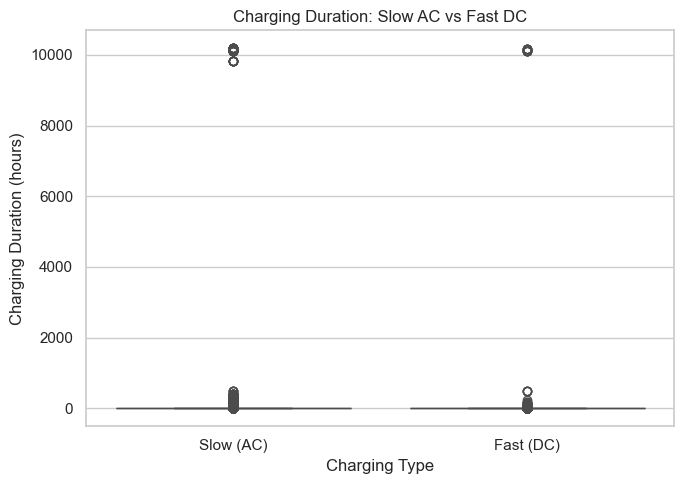

In [75]:
charging_df = final_trip_data.copy()

# Keep only actual charging events
charging_df = charging_df[charging_df['charge_type'] != 'None']

plt.figure(figsize=(7,5))
sns.boxplot(
    data=charging_df,
    x='charge_type',
    y='parking_time'
)

plt.xlabel('Charging Type')
plt.ylabel('Charging Duration (hours)')
plt.title('Charging Duration: Slow AC vs Fast DC')
plt.tight_layout()
plt.show()


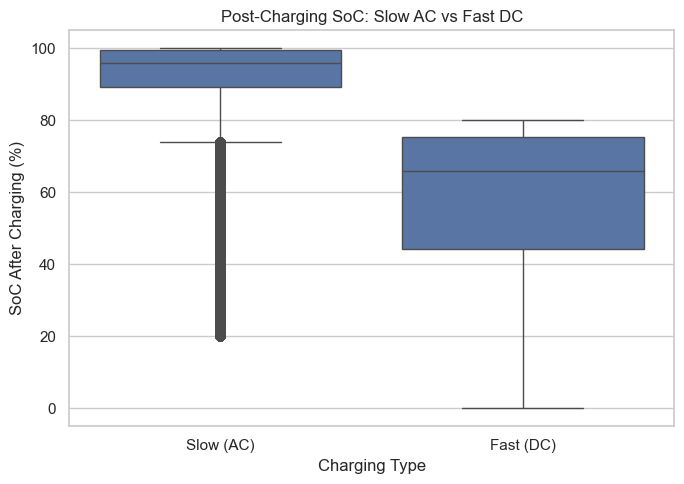

In [76]:
plt.figure(figsize=(7,5))
sns.boxplot(
    data=charging_df,
    x='charge_type',
    y='soc_after'
)

plt.xlabel('Charging Type')
plt.ylabel('SoC After Charging (%)')
plt.title('Post-Charging SoC: Slow AC vs Fast DC')
plt.tight_layout()
plt.show()


Running Baseline Simulation...
Running Slow AC Only Simulation...


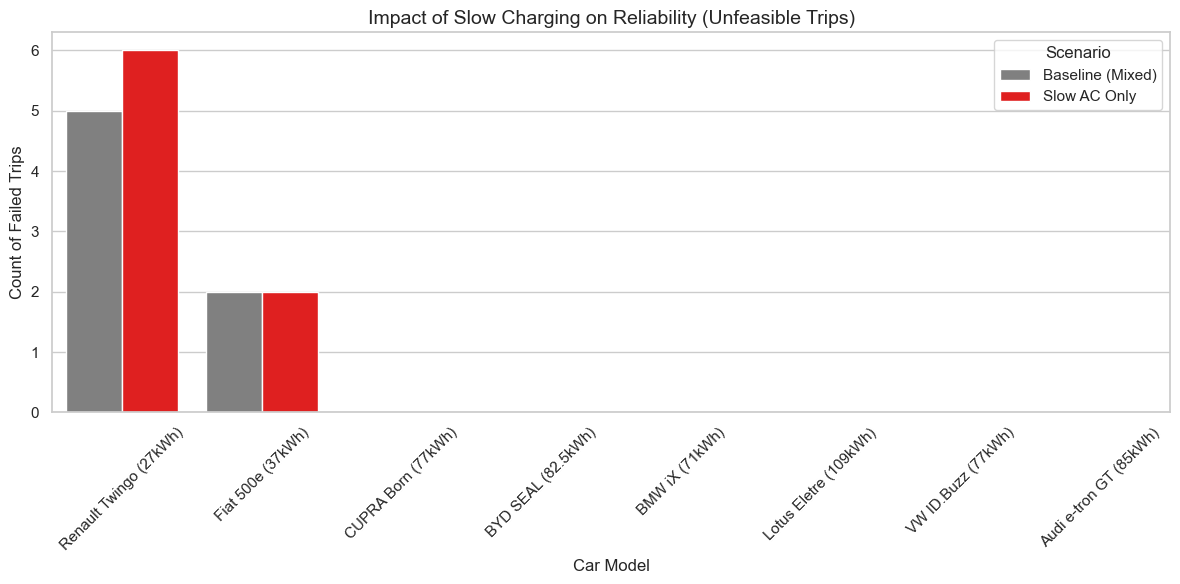

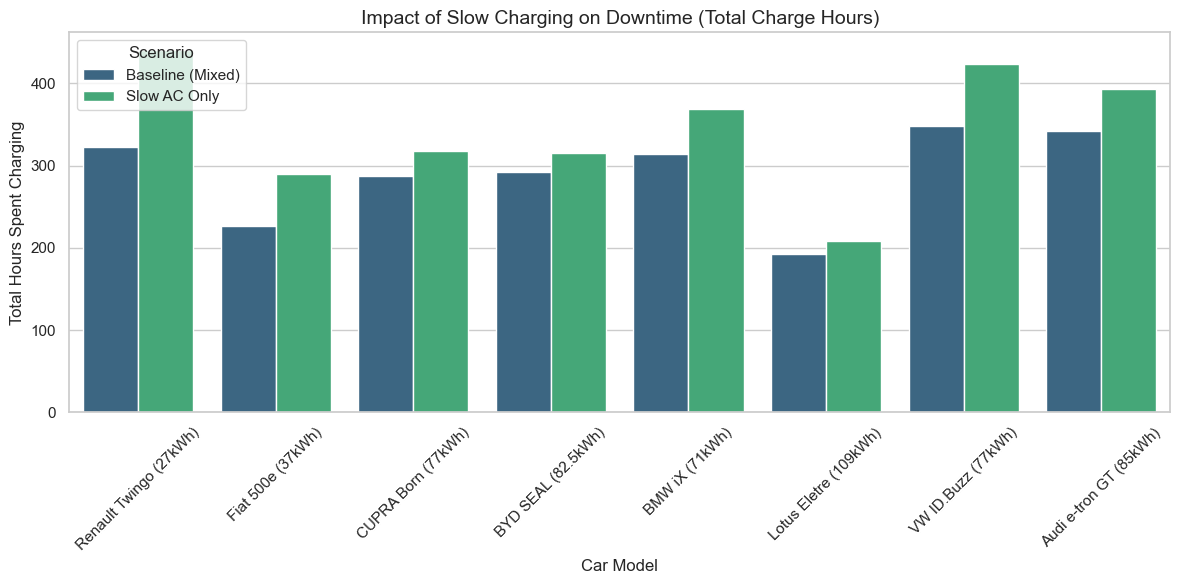


--- Comparison Table ---
                Car Model          Scenario  Unfeasible Trips  \
7  Audi e-tron GT (85kWh)  Baseline (Mixed)                 0   
7  Audi e-tron GT (85kWh)      Slow AC Only                 0   
4          BMW iX (71kWh)  Baseline (Mixed)                 0   
4          BMW iX (71kWh)      Slow AC Only                 0   
3      BYD SEAL (82.5kWh)  Baseline (Mixed)                 0   
3      BYD SEAL (82.5kWh)      Slow AC Only                 0   
2      CUPRA Born (77kWh)  Baseline (Mixed)                 0   
2      CUPRA Born (77kWh)      Slow AC Only                 0   
1       Fiat 500e (37kWh)  Baseline (Mixed)                 2   
1       Fiat 500e (37kWh)      Slow AC Only                 2   
5   Lotus Eletre (109kWh)  Baseline (Mixed)                 0   
5   Lotus Eletre (109kWh)      Slow AC Only                 0   
0  Renault Twingo (27kWh)  Baseline (Mixed)                 5   
0  Renault Twingo (27kWh)      Slow AC Only                 6   

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
# Cars Configuration (including AC/DC Power limits)
cars_config = {
    "Renault Twingo (27kWh)": {"capacity": 27.5, "ac_power": 6.6, "dc_power": 50.0, "consumption": {"U": 0.096, "A": 0.162, "E": 0.128, "_": 0.128}},
    "Fiat 500e (37kWh)": {"capacity": 37.3, "ac_power": 11.0, "dc_power": 85.0, "consumption": {"U": 0.105, "A": 0.173, "E": 0.138, "_": 0.138}},
    "CUPRA Born (77kWh)": {"capacity": 77.0, "ac_power": 11.0, "dc_power": 175.0, "consumption": {"U": 0.118, "A": 0.186, "E": 0.150, "_": 0.150}},
    "BYD SEAL (82.5kWh)": {"capacity": 82.5, "ac_power": 11.0, "dc_power": 150.0, "consumption": {"U": 0.121, "A": 0.181, "E": 0.149, "_": 0.149}},
    "BMW iX (71kWh)": {"capacity": 71.0, "ac_power": 11.0, "dc_power": 148.0, "consumption": {"U": 0.138, "A": 0.215, "E": 0.175, "_": 0.175}},
    "Lotus Eletre (109kWh)": {"capacity": 109.0, "ac_power": 22.0, "dc_power": 367.0, "consumption": {"U": 0.156, "A": 0.242, "E": 0.196, "_": 0.196}},
    "VW ID.Buzz (77kWh)": {"capacity": 77.0, "ac_power": 11.0, "dc_power": 175.0, "consumption": {"U": 0.154, "A": 0.252, "E": 0.200, "_": 0.200}},
    "Audi e-tron GT (85kWh)": {"capacity": 85.0, "ac_power": 11.0, "dc_power": 268.0, "consumption": {"U": 0.150, "A": 0.227, "E": 0.185, "_": 0.185}}
}

# Generate Synthetic Trips (Same logic as before)
def generate_synthetic_data(n_vehicles=10, trips_per_vehicle=50):
    data = []
    roads = ['U', 'A', 'E'] 
    np.random.seed(42) 
    
    for vid in range(n_vehicles):
        current_time = pd.Timestamp('2024-01-01 08:00:00')
        for tid in range(trips_per_vehicle):
            # Using mean=3.5 to create some long trips for stress testing
            dist = np.random.lognormal(mean=3.5, sigma=0.8) 
            dist = np.clip(dist, 2, 600) 
            duration_hours = dist / np.random.uniform(30, 100)
            road_type = np.random.choice(roads)
            
            start_time = current_time
            stop_time = start_time + pd.Timedelta(hours=duration_hours)
            
            data.append({
                'vehicle_id': vid,
                'trip_id': tid,
                'start_time': start_time,
                'stop_time': stop_time,
                'total_distance': dist,
                'road': road_type
            })
            parking_hours = np.random.exponential(scale=4.0)
            current_time = stop_time + pd.Timedelta(hours=max(0.5, parking_hours))
    return pd.DataFrame(data)

# ==========================================
# 2. COMPARATIVE SIMULATION ENGINE
# ==========================================
def run_comparative_simulation(trips_df, config, force_slow_ac=False):
    """
    Runs the simulation. If force_slow_ac=True, ignores DC charging triggers.
    """
    results = []
    
    for model_name, params in config.items():
        capacity = params['capacity']
        ac_power = params['ac_power']
        dc_power = params['dc_power']
        
        unfeasible_count = 0
        total_charge_time = 0.0
        
        # Group by vehicle to maintain timeline state
        for vid, vehicle_trips in trips_df.groupby('vehicle_id'):
            soc = capacity
            trip_list = vehicle_trips.sort_values('start_time').to_dict('records')
            
            for i, trip in enumerate(trip_list):
                # --- 1. Driving Phase ---
                dist = trip['total_distance']
                cons = params['consumption'].get(trip['road'], 0.15)
                needed = dist * cons
                
                if soc >= needed:
                    soc -= needed
                else:
                    unfeasible_count += 1
                    soc = capacity * 0.2 # Rescue logic
                
                # --- 2. Charging Phase ---
                if i < len(trip_list) - 1:
                    park_duration = (trip_list[i+1]['start_time'] - trip['stop_time']).total_seconds() / 3600
                    
                    if park_duration > 0:
                        # LOGIC: Determine Charging Power
                        if force_slow_ac:
                            # Scenario: AC Only
                            power = ac_power
                        else:
                            # Scenario: Baseline (Smart DC use)
                            # Trigger DC if battery low (<20%) or time is short (<2h)
                            if soc < (capacity * 0.20) or (park_duration < 2.0 and soc < capacity * 0.8):
                                power = dc_power
                            else:
                                power = ac_power
                        
                        # Apply Charge
                        needed_to_full = capacity - soc
                        time_to_full = needed_to_full / power if power > 0 else 0
                        actual_time = min(park_duration, time_to_full)
                        
                        added_energy = power * actual_time
                        soc = min(capacity, soc + added_energy)
                        total_charge_time += actual_time
        
        results.append({
            'Car Model': model_name,
            'Scenario': 'Slow AC Only' if force_slow_ac else 'Baseline (Mixed)',
            'Unfeasible Trips': unfeasible_count,
            'Total Charging Time (h)': total_charge_time
        })
        
    return pd.DataFrame(results)

# ==========================================
# 3. EXECUTION & PLOTTING
# ==========================================

# 1. Generate Data
trips_data = generate_synthetic_data()

# 2. Run Both Scenarios
print("Running Baseline Simulation...")
df_baseline = run_comparative_simulation(trips_data, cars_config, force_slow_ac=False)

print("Running Slow AC Only Simulation...")
df_slow = run_comparative_simulation(trips_data, cars_config, force_slow_ac=True)

# 3. Combine Results
df_compare = pd.concat([df_baseline, df_slow])

# 4. Plotting
sns.set_theme(style="whitegrid")

# Plot 1: Unfeasible Trips Comparison
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_compare, 
    x='Car Model', 
    y='Unfeasible Trips', 
    hue='Scenario', 
    palette={'Baseline (Mixed)': 'grey', 'Slow AC Only': 'red'}
)
plt.title('Impact of Slow Charging on Reliability (Unfeasible Trips)', fontsize=14)
plt.ylabel('Count of Failed Trips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2: Total Charging Time Comparison
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_compare, 
    x='Car Model', 
    y='Total Charging Time (h)', 
    hue='Scenario', 
    palette='viridis'
)
plt.title('Impact of Slow Charging on Downtime (Total Charge Hours)', fontsize=14)
plt.ylabel('Total Hours Spent Charging')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Display Data Table
print("\n--- Comparison Table ---")
print(df_compare.sort_values(['Car Model', 'Scenario']))